In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)

In [6]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

np.int64(22)

EDA

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Churn', ylabel='count'>

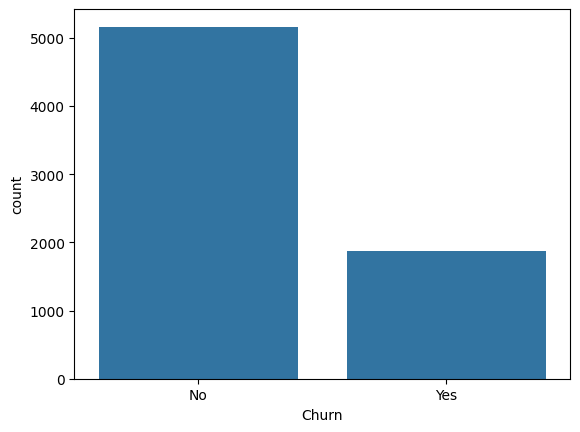

In [8]:
sns.countplot(x='Churn', data=df)

Churn Distribution

<Axes: xlabel='gender', ylabel='count'>

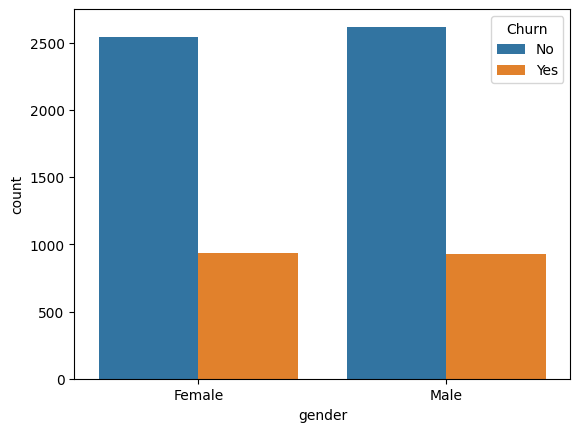

In [9]:
sns.countplot(x='gender', hue='Churn', data=df)

Gender vs Churn

<Axes: xlabel='Contract', ylabel='count'>

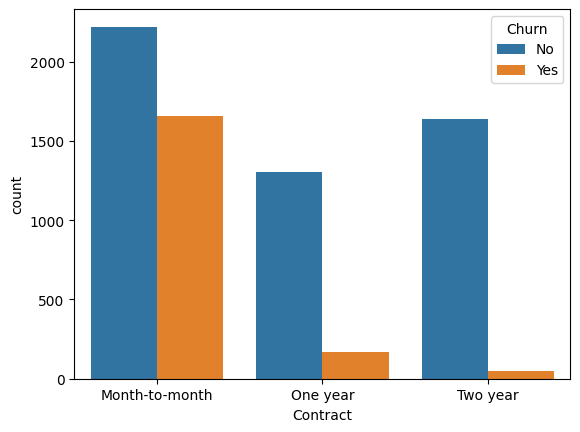

In [10]:
sns.countplot(x='Contract', hue='Churn', data=df)

Contract vs Churn

<Axes: xlabel='InternetService', ylabel='count'>

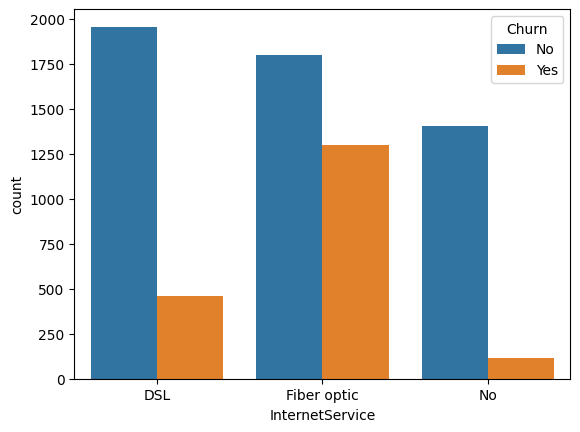

In [11]:
sns.countplot(x='InternetService', hue='Churn', data=df)

Internet Service vs Churn

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

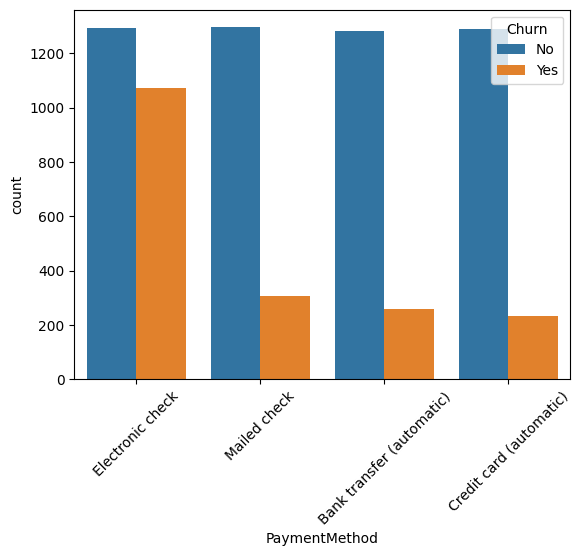

In [12]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)

Payment Method vs Churn

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

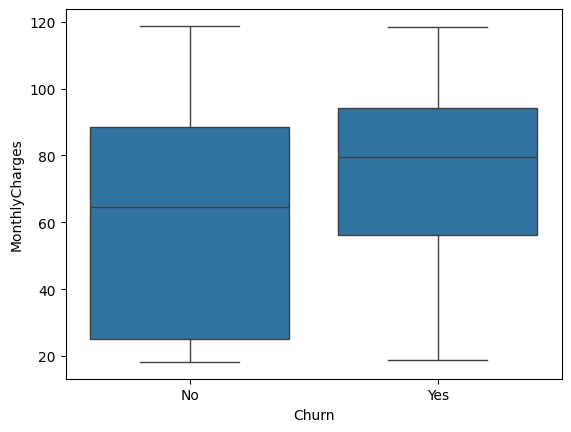

In [13]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

Monthly Charges vs Churn

<Axes: xlabel='Churn', ylabel='tenure'>

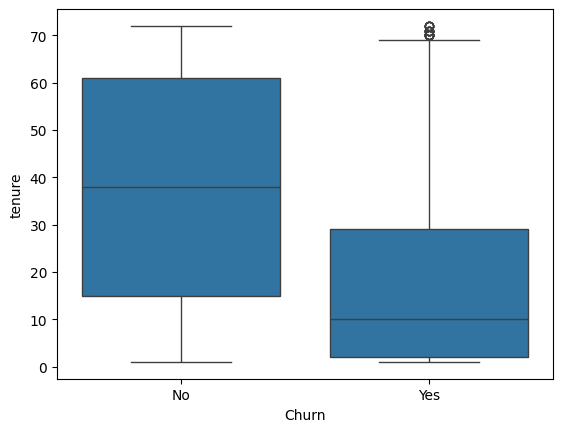

In [14]:
sns.boxplot(x='Churn', y='tenure', data=df)

Tenure vs Churn

Machine Learning

In [15]:
df = pd.get_dummies(df, drop_first=True)

In [16]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

Target

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

split

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7874911158493249

In [23]:
df = pd.get_dummies(df, drop_first=True)

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Final Model Results